In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import quimb.tensor as qtn
import tnprob
import torch
import time
import scipy.stats

In [25]:
# Load the Bayesian network as a tensor network consisting pytorch tensors
tn = tnprob.open_bif("covid_measures.bif")
tn.apply_to_arrays(torch.tensor)

In [ ]:
probability = {'Country.Finance': 0}  # <- meaning: COUNTRYFIN = "Agree", i.e. answering "agree" to the question "The Coronavirus outbreak will have serious economic consequences in your country"
df = tnprob.top_sensitivity_values(tn, probability=probability, evidence={})

# Filter out CPT entries whose entry is too close to 0 or 1 (because a beta distribution of fixed variance centered in such a CPT will be ill-defined)
df = df[(df['value'] > 0.02+1e-5) & (df['value'] < 0.98-1e-5)]

# Filter out CPT entries whose sensitivity value is negligible
nzidx = np.where(df['sensitivity_value'].values > 1e-5)[0]
df = df.iloc[nzidx, :]

In [31]:
# In this example, we'll discretize each degree of freedom (uncertain parameter) using 8 points
disc = 8


# Encode the uncertainty (in this example, distributed as a beta centered on the original theta value and variance equal to 0.02)
def uncertainty_fun(x):

    def get_beta_points(mean, variance, npoints):
        alpha = mean*(-mean**2 + mean - variance)/variance
        beta = (mean - 1)*(mean**2 - mean + variance)/variance
        return scipy.stats.beta.ppf(np.linspace(0+1/npoints/2, 1-1/npoints/2, npoints), alpha, beta)

    return get_beta_points(x, variance=0.02, npoints=disc)

# Encode the uncertain entries into a modified tensor network, and print some statistics
start = time.time()
tnmodified = tnprob.encode_cpt_uncertainty(tn, df=df, uncertainty_fun=uncertainty_fun)
print('Number of uncertainties:', len(df))
print('Time to encode the uncertainties:', time.time()-start)
print('Modified number of elements before modification:', tnprob.numel(tn))
print('Modified number of elements after modification:', tnprob.numel(tnmodified))
print('Original treewidth before modification:', tnprob.get_treewidth(tn))
print('Modified treewidth after modification:', tnprob.get_treewidth(tnmodified))
print('Largest n. uncertainties in a single CPT:', max([len(group) for _, group in df.groupby("child")]))


Number of uncertainties: 55
Time to encode the uncertainties: 1.889286756515503
Modified number of elements before modification: 588
Modified number of elements after modification: 12783
Original treewidth before modification: 8
Modified treewidth after modification: 7
Largest n. uncertainties in a single CPT: 18


In [28]:
# Calculate the Sobol indices (variance components + total indices) for each uncertain CPT
inputs = list(df.index)
z = qtn.TensorNetwork([qtn.Tensor(torch.ones(disc)/disc, inds=[input]) for input in inputs])
indices = tnprob.sobol_all(tnmodified, inputs, output=next(iter(probability.keys())), values=[1, 0, 0], z=z)
# indices = sobol_all(tnmodified, inputs, output=next(iter(probability.keys())), values=[0, 0, 1, 0, 0], z=z)
df['variance_component'] = list(indices['variance_components'].values())
df['total_index'] = list(indices['total_indices'].values())

Found V = 1.0631675336516195e+98

child                 Country.Finance
coordinates              [0, 2, 0, 0]
value                        0.973207
sensitivity_value            0.168369
variance_component            0.00011
total_index                  0.000112
Name: P(Country.Finance=0 | Measures.Health=2, Measures.Justified=0, Personal.Finance=0), dtype: object


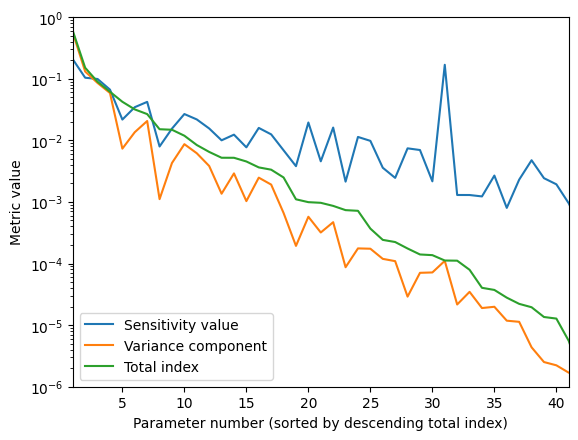

In [ ]:
# Plot them, sorted by decreasing total index
df = df.sort_values(by='total_index', ascending=False)
plt.plot(np.arange(1, len(df)+1), df['sensitivity_value'].values, label='Sensitivity value')
plt.plot(np.arange(1, len(df)+1), df['variance_component'].values, label='Variance component')
plt.plot(np.arange(1, len(df)+1), df['total_index'].values, label='Total index')
plt.xlim(1, 41)
plt.yscale('log')
plt.legend()
plt.ylim(1e-6, 1)
plt.xlabel('Parameter number (sorted by descending total index)')
plt.ylabel('Metric value')
plt.show()